In [6]:
from IPython.display import Image

# biomass: everything but RNA and protein is the same as RECON2.2 for now?

#### Variable definitions

#### 1) Coupling enzyme synthesis and enzyme catalysis

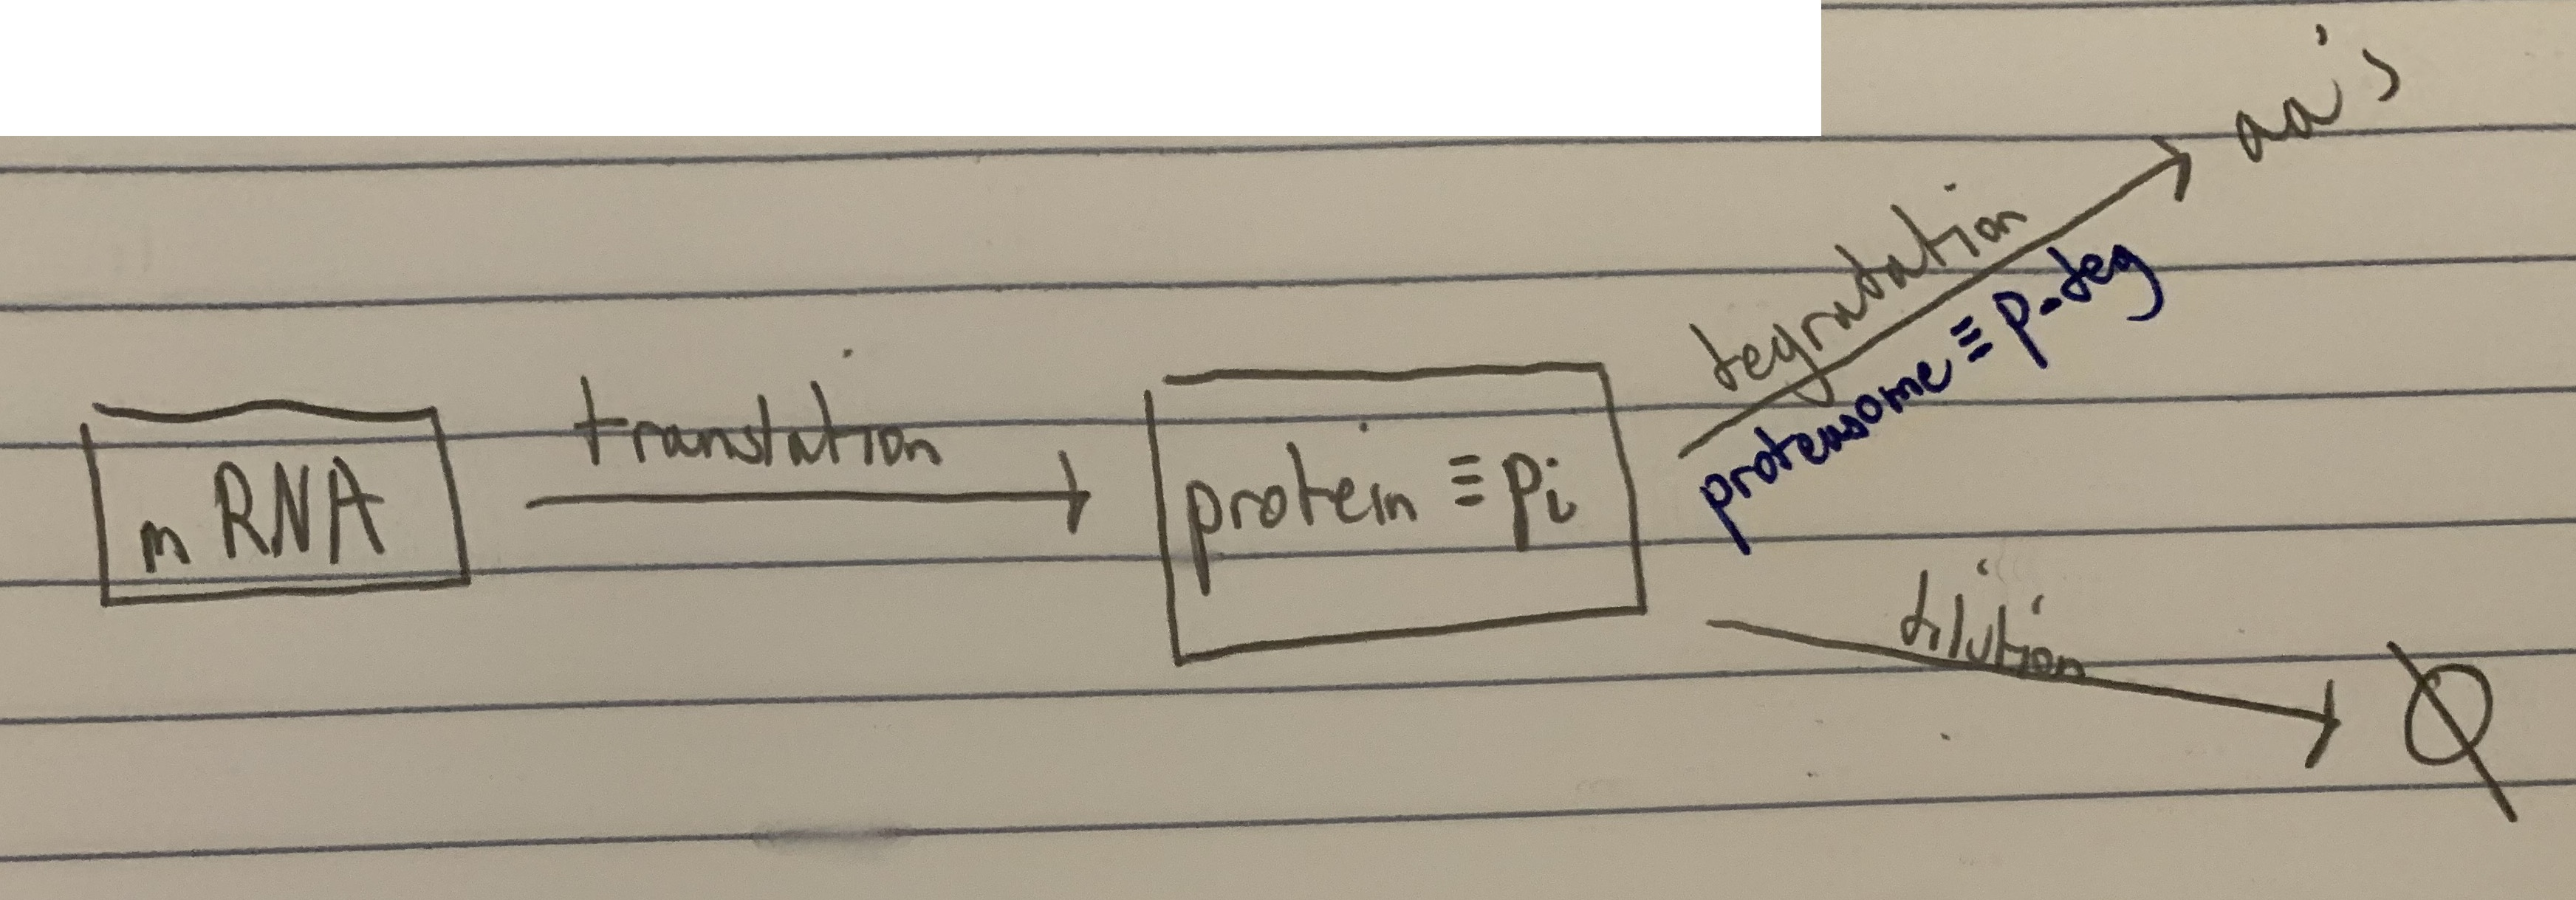

In [12]:
Image(filename = "/Users/joycebaghdassarian/Downloads/protein_synthesis.jpg", width=700, height=275)

$
P \equiv \text{total cellular protein mass} \>~\> \text {(g gDW}^{-1}) \\
R \equiv \text{total cellular RNA mass} \>~\> \text {(g gDW}^{-1}) \\
m_\text{aa} \equiv \text{molecular weight of average amino acid} \>~\> \text {(g mmol}^{-1}) \\
m_\text{nt} \equiv \text{molecular weight of average mRNA nucleotide} \>~\> \text {(g mmol}^{-1})\\
f_\text{mRNA} \equiv \text{fraction of RNA that is mRNA}\\~\\
i \in \text{metabolic_enzymes} \\
p_i \equiv \text{cobra_metabolite}_\text{protein} \>~\> \text {(likely an enzyme)} \\
k_i \equiv \text{first-order rate constant for degradation of target protein substrate} p_i \\
p_\text{deg,i} \equiv \text{cobra_metabolite}_\text{proteolytic_enzyme} \>~\> \text{(e.g., proteasome)}\\
k_\text{deg,i} \equiv \text{catalytic rate constant for proteolytic enzyme} p_\text{deg,i}  \text{catalyzing degradation of target protein substrate} p_i
$

(A)Term for the flux through synthesis
$$
(i) \> \frac{d[p_{i}]}{dt} = 0 = v_{\text{synthesis,i}} - [v_{dilution,i} + v_{degradation,i}] \\
(ii) \> v_{dilution,i} = \frac{1}{T_{d}}[p_{i}] = \mu[p_{i}] \\
(iii) \> v_{degradation} = f([p_{i}]) \\~\\
$$
(B) Term for the flux through reaction
$$
v_{catalysis,i} = \frac{v_\text{max}[S]}{K_{m} + S} = \frac{k_\text{cat,i}[p_{i}][S]}{K_{m} + S} \\
\>~\> = k_\text{cat,i}[p_{i}] \>~\> \text {assuming } K_m << [S]\\
\>~\> \geq k_\text{eff,i}[p_{i}] \\ \\ 
[p_i] = \frac{v_{catalysis,i}}{k_\text{cat,i}} \\~\\
$$
(C) substitution
$$
\> v_{\text{synthesis,i}} = \mu[p_i] + f([p_{i}]) \>~\> \text{from part A} \\
\>~\> = \frac{1}{k_\text{eff,i}}(\mu + f([p_{i}]))v_{catalysis,i} \>~\> \text{from part B, with }f([p_{i}]) \text{ in a reduced form}\\~\\~\\
$$

$
\text{Laurence suggestions } f([p_{i}]) = k_\text{deg,i}[p_i][p_{deg}] \text{ , as some sort of pseudo-first order Michaelis-Menten. While this makes intuitive sense, I'm not sure how to derive it from rate laws}\\~\\
\text{I feel that } v_{degradation} \text{ should either be a Michaelis-Menten derived } k_{deg}[p_{deg}] \text{ or a first-order } k_i[p_i]\\
\text{The first-order version allows a simple solution for this coupling constraint, with } k_i \equiv \text{ the constant } k_\text{prot, deg} \text{ extensively discussed in part 2}\\
$

##### Questions/ToDo:
$
\text {0) Figure out a term for } f([p_i])\\
\text {1) How to deal with complexes vs individual proteins? (consider the network)}\\
\text {Easiest would probably be to rewrite to make complex formation irreversible and degradation directly on complex, }\\
\text {but this doesn't feel like the most resource efficient in terms of multi-localization}
\text {2) What should f([p_{i}]) be?}\\
\text {3) Since } \text{units } \mu \neq \text{units } v \text { (see v_dilution), how is growth found?}
$

---

#### 2) mRNA and protein
##### 2.1.0) COBRAME original coupling constraints

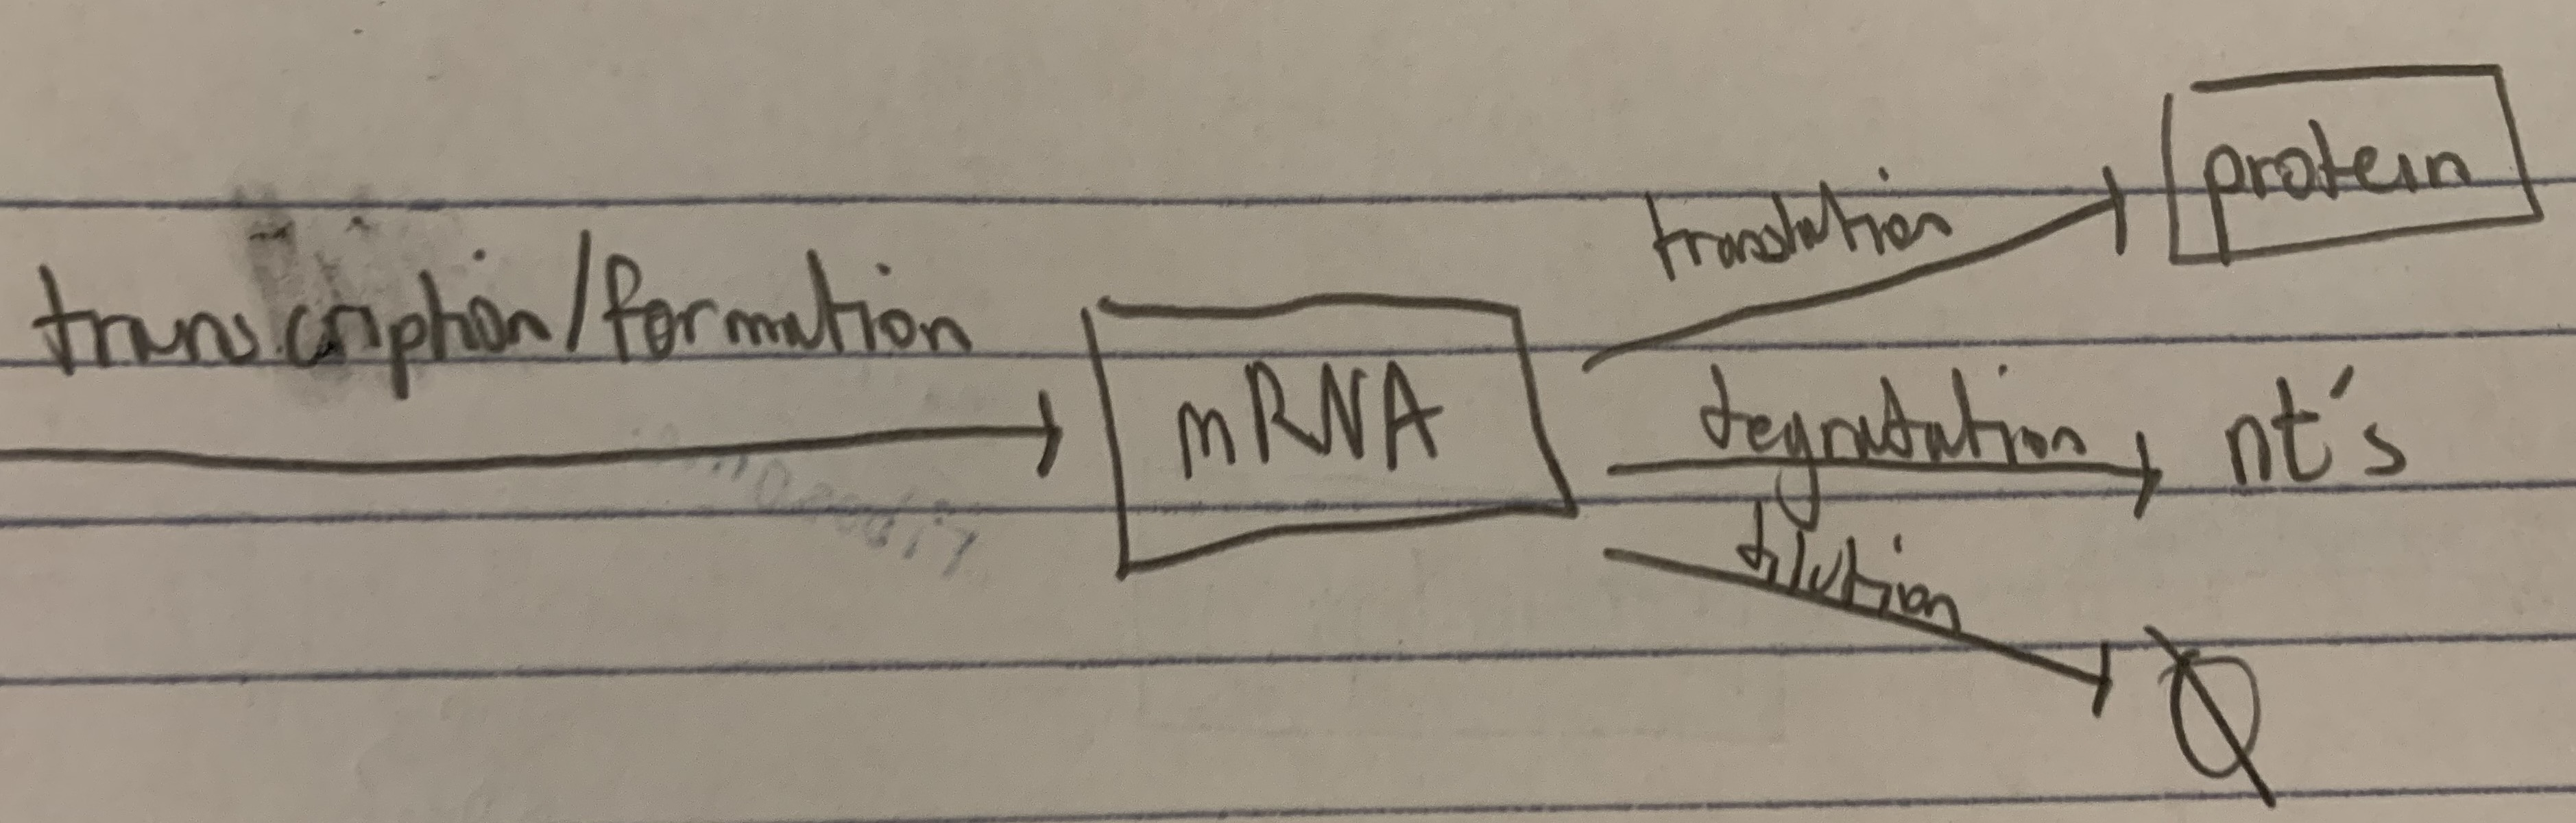

In [14]:
Image(filename = "/Users/joycebaghdassarian/Downloads/ecoli_mrna_synthesis.jpg", width=700, height=275)

Define variables: 
$j\in{mRNA}$
$$
(A) \>~\> v_\text{dilution,j} = \mu * [mRNA_j] \\
(B) \>~\> v_\text{degradation,j} = k_\text{deg,j}*[mRNA_j] \\
(C) \>~\> [mRNA] = \frac{Rf_\text{mRNA}}{m_\text{nt}} \\
(D)\>~\> (i) \> v_\text{translation,j} = \frac{\mu\text{P}}{m_\text{aa}}; \> (ii) \> v_\text{translation,j} = k_\text{mRNA,j}[mRNA_j]; \> (iii) \> c_\text{mRNA} = \frac{m_\text{nt}}{f_\text{mRNA}m_\text{aa}} ; \> (iv) \> \frac{\text{R}}{\text{P}} = \frac{\mu}{\kappa_t} + r_0\\
$$
Combining the equations in (D):
$$
k_\text{mRNA,j} = \frac{c_\text{mRNA}\kappa_t\mu}{\mu + r_0\kappa_t}\\
$$
O'Brien 2013 coupling constraints:
$$
(1) \>~\> v_\text{dilution,j} \geq \alpha_1v_\text{degradation,j} \>\text{,which gives}\> \alpha_1 = \frac{v_\text{dilution,j}}{v_\text{degradation,j}} \\
(2) \>~\> v_\text{degradation,j} \geq \alpha_2v_\text{translation,j} \>\text{,which gives}\> \alpha_2 = \frac{v_\text{degradation,j}}{v_\text{translation,j}}
$$
Using A-Diii one can solve for the coupling coefficients:
$$
(1) \>~\> \alpha_1 = \frac{\mu}{k_\text{deg,j}} \\
(2) \>~\> \alpha_2 = \frac{3k_\text{deg,j}Rf_\text{mRNA}m_\text{aa}}{\mu P m_\text{nt}} = \frac{3k_\text{deg,j}(\mu + r_0\kappa_t)}{c_\text{mRNA}\kappa_t\mu}\\
$$
##### 2.1.1) Confusion about COBRAME derivation 
The COBRAME paper does not have $\alpha_1$ but instead an $\alpha_3 \equiv \frac{v_\text{formation}}{v_\text{translation}}, \text{and } \alpha_3 = \alpha_2*\alpha_1.$
$
\\
$
Also, note that the factor of 3 (for 3 nt's per amino acid) is switched from numerator to denominator from O'brien 2013 to COBRAME 2016
$
\\
$
This doesn't make too much sense to me. If we use steady state to take:
$$
v_\text{formation,j} =  v_\text{dilution,j} + v_\text{degradation,j} + v_\text{translation,j} \>~\> \text{by setting} \>~\> \frac{d[mRNA_j]}{dt} = 0 \\
$$
then
$$
\frac{v_\text{formation}}{v_{translation}} = \frac{v_\text{dilution}}{v_{translation}} + \frac{v_\text{degradation}}{v_{translation}} + \frac{v_\text{translation}}{v_{translation}} = (\alpha_1*\alpha_2) + \alpha_2 + 1\\
\text{Do they assume } \alpha_1*\alpha_2 >> \alpha_2 + 1 \text{?}
$$

Note that equation D iv is from Scott et. al. 2010 and is specific to E.coli. These derivations largely depend on D(iv), which is E. coli specific, as well as D(i), which I don't understand. A simpler solution would be to keep the coupling constraint 1 derivation, and use the Lerman 2012 derivation of coupling constraint 2 instead of this version

##### Questions:
$
\text {1) How did COBRAME arrive at equation (Di)?}\\
\text {2) How does COBRAME couple formation of mRNA to translation of mRNA (alpha_3)?} \\
$

##### 2.2) HUMANME mrna/protein coupling

##### Options going forward:
$
\text {1) Use COBRAME coupling constraints despite equation D(iv)}\\
\text {2) Learn alpha 1 and alpha 2 from the data} \\
\text {3) Try my own first principles derivation, perhaps using Uri Alon's Crick Space paper}
$

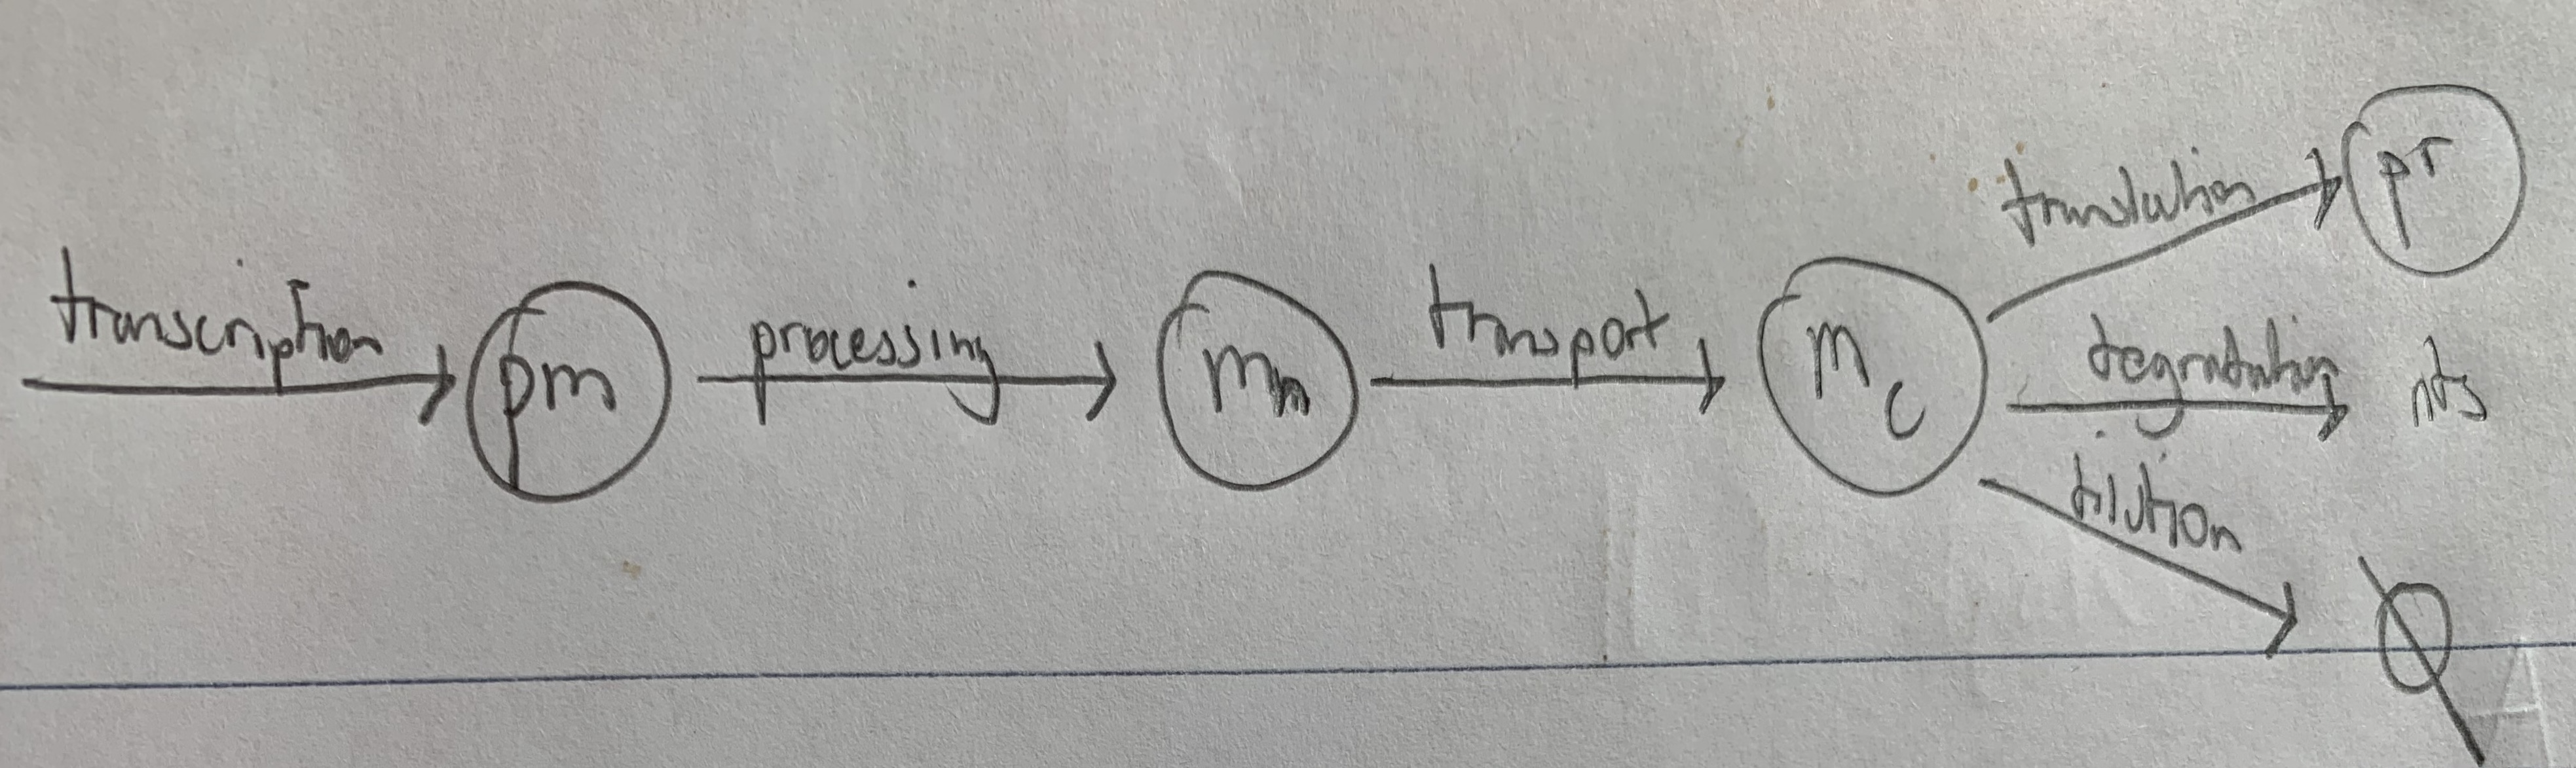

In [9]:
Image(filename = "/Users/joycebaghdassarian/Downloads/mrna_network.png", width=700, height=275)

$ 
\text{From steady-state, } v_\text{transcription} = v_\text{processing} = v_\text{transport} = v_\text{translation} + v_\text{degradation} + v_\text{dilution} \\
\text{We can keep equation A for } v_\text{dilution} \\
\text{From steady-state, Michealis-Menten kinetics and first-order rate laws, we have all the following possible equations: } \\~\\
$
$$
v_\text{transcription} = k_\text{RNAP}[RNAP] = k_\text{splicesome}[SPLICESOME] = k_\text{transporter}[TRANSPORTER] \\
$$
$
\hspace{193pt}=k_\text{pm}[pm] \hspace{75pt} = k_{m_n}[m_n] \\
$
$$
v_\text{translation} = k_\text{ribo}[ribo] = k_{m_c, translation}[m_c]\\ 
v_\text{degradation} = k_\text{nuclease}[nuclease] = k_{m_c, deg}[m_c]\\ 
v_\text{dilution} = \mu[m_c]\\ 
$$
$
\text{In Uri Alon's Crick Space formulation: }\\
$
$$
m \equiv mrna \\
p \equiv protein \\
\frac{dm}{dt} = \beta_m - \alpha_m[m] \\
\frac{dp}{dt} = \beta_p[m] - \alpha_p[p]\\
$$
$
\text{The variables are analgous to our network as follows: } \\
$
$$
\beta_m \equiv v_\text{transcription} \\
\beta_p \equiv k_{m_c, translation} \\
\alpha_m \equiv k_{m_c, deg} + \mu \\ 
\alpha_p \equiv k_{prot, deg} + \mu \text{ if we treat the degradation term from 1A(iii) as a first-order reaction}
$$

$
\text{We can take the following as knowns from Uri Alon's Crick Space formulation :}\\
$
$$
k_{m_c, deg} = 0.06 h^{-1}  \>~\>\text{Note that the paper assumes } k_{m_c, deg} >> \mu \>~\>\text{s.t.}\>~\> \alpha_m = k_{m_c, deg}\\
\text{Additionally, an alternate value reported in the same paper for } k_{m_c, deg} = 0.14 h^{-1} \\
k_{prot, deg} = 0.02 h^{-1}
$$
$
\text{Thus the derivation for the first coupling constraint becomes exactly that of the ECOLIME:}\\
$
$$
\alpha_1 = \frac{v_\text{dilution}}{v_\text{degradation}} = \frac{\mu[m_c]}{k_{m_c, deg}[m_c]} = \frac{\mu}{k_{m_c, deg}} \\
$$
$ 
\textbf{Note that, since decay rates vary much less from gene-to-gene, couplign constraints that depend on a constant decay rate should be okay}\\
\text{For } \alpha_2 \text{, there are a couple options:}\\~\\
\text{Option 0 - Assume Scot et al. holds and use their relationship }\\
\text{Option 1 - Directly Calculate: }\\
$

$$
\alpha_2 = \frac{3v_\text{degradation}}{v_\text{translation}} = \frac{3k_{m_c, deg}[m_c]}{k_{m_c, translation}[m_c]} = \frac{3k_{m_c, deg}}{k_{m_c, translation}}\\
$$

$ 
\text{Option 2 - Back Calculate from alpha_3: }\\
$
$$
\text{Step 1: }\>\alpha_3 = \frac{v_\text{transcription}}{v_\text{translation}} = \frac{\beta_m}{\beta_p[m_c]} \>~\> \text{Where the translation to transcription rate ratio (} \frac{\beta_m}{\beta_p} \text{) is a constant provided by Uri Alon's paper}\\
\text{Step 2: }\>\alpha_2 = \frac{\alpha_3}{\alpha_1}\\
$$
$ 
\text{For this, we would still need some term for [m_c]-->potentially N_m = the COBRAME formulation for converting between concentration and} \\ \text{number of mrna then divide by V_cell (= f(mu)?); alternatively [m] = r[p] where r is the correlation between mrna and protein, then use the first equation from part A to solve for p or set p = f(B_p) from fig 3d of schwanhausser}\\
\text{Alternatively, can use a proxy variable in production of mRNA<--don't necessarily need a term for m_c}
$

$
\text{Option 3: coupling constraint as a function of specific cell objective or condition }\\
\text{could incorporate Uri Alon's fitness function and try replacing growth with other fluxes}\\

\text{Option 4: data-drive tuning of coupling constraints}
$

$
\text{Sources for translation and transcription rates can be found in notesinclude \text{ Crick Space, Fig 3d of Schwanhausser 2010, anbeing a data-driven value (perhaps gene-specific). Sources include Alon's Crick Space and Fig3d of Schwanhäusser 2010}
$

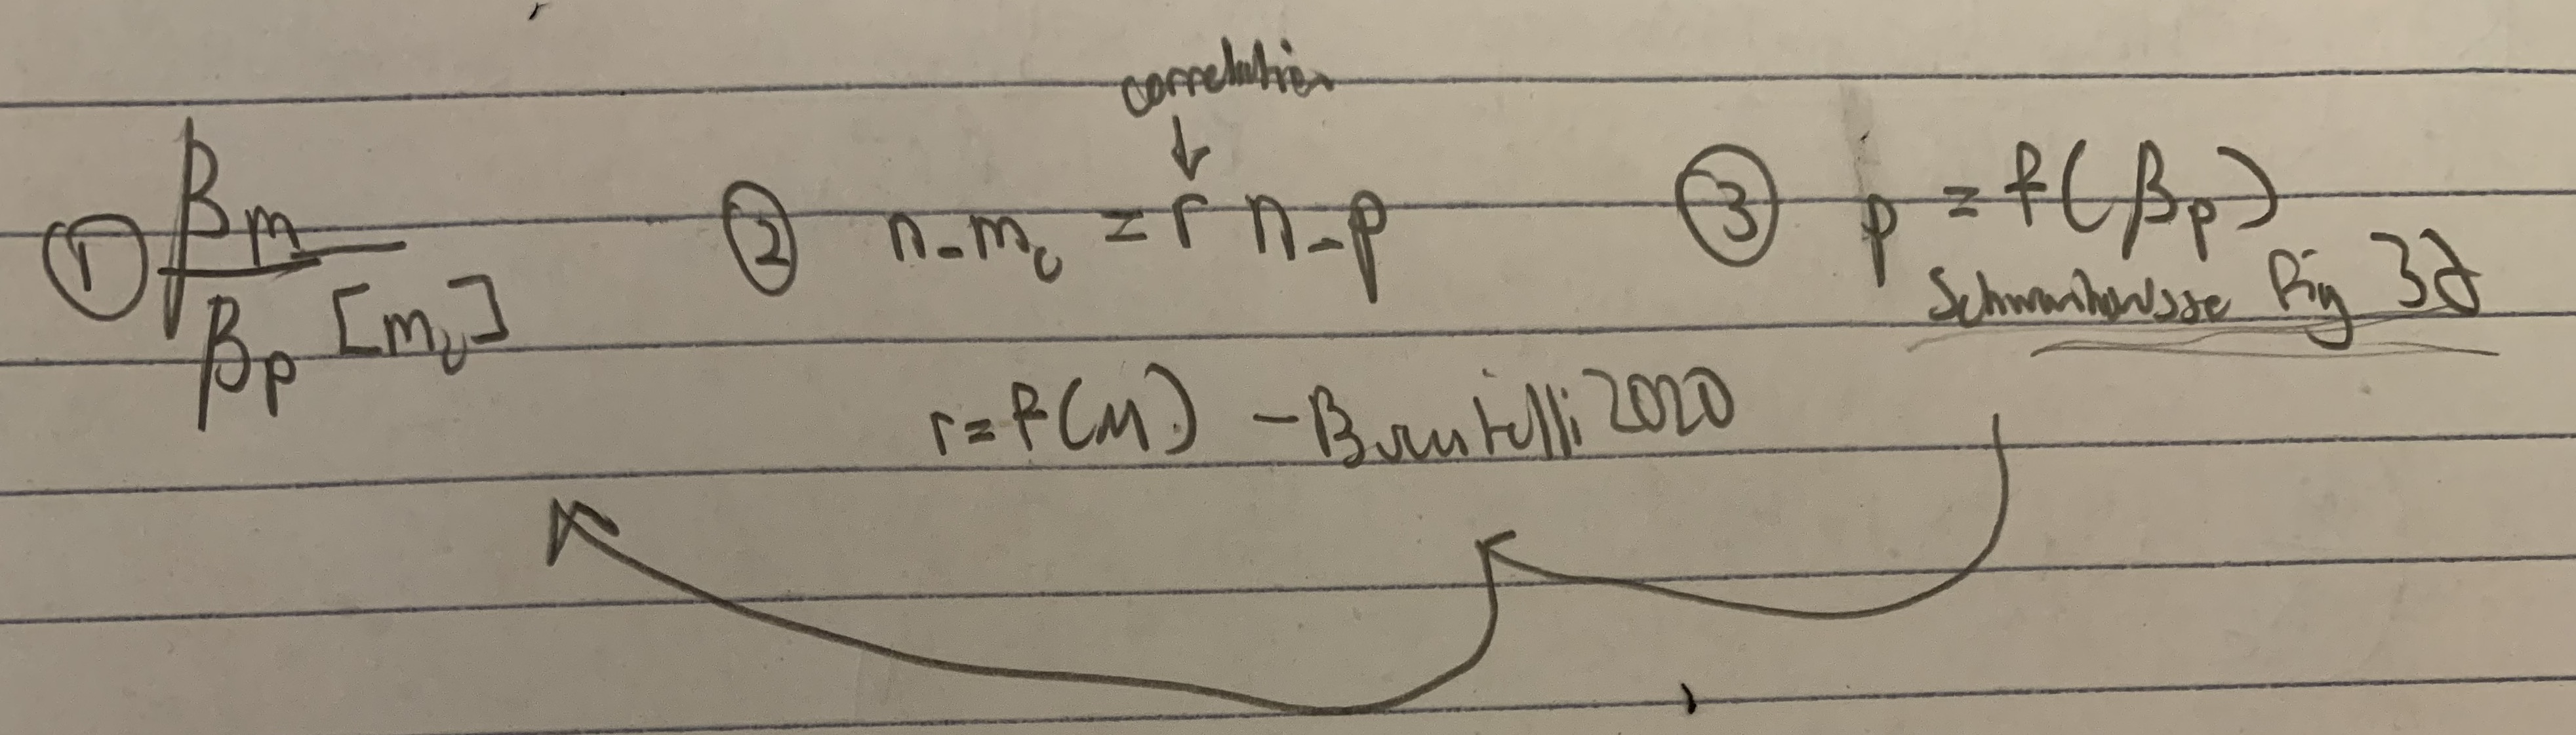

In [17]:
Image(filename = "/Users/joycebaghdassarian/Downloads/coupling_deriv.jpg", width=700, height=275)

Equation 2 may need to account for the fact that there are many more protein copie than mrna copies. Scaling factor (or it's baked into equation three). Could also just have [m_c] as a function of growth (some baseline at no growth, which increases with growth - yeast quiescent paper and mammalian proliferation paper)

Why note log2/doubling_time rather than mu in the dilution equations?

##### Questions/ToDo:
$
\text {1) Figure out an complete, appropriate term for alpha_2 or alpha_3}
$

---

#### 2) Total protein fraction

$$
\sum_i p_i \leq P_\text{tot}
$$